In [31]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import os

In [32]:
OLLAMA_API_URL = os.getenv("OLLAMA_API_URL")
OLLAMA_API_KEY = os.getenv("OLLAMA_API_KEY")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gemma4:e2b")

In [45]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv()

# Initialize with your environment variables
llm = ChatOllama(
    base_url=os.getenv("OLLAMA_API_URL"),
    api_key=os.getenv("OLLAMA_API_KEY"), 
    model=os.getenv("OLLAMA_MODEL", "gemma4:e2b"),
)

# result = llm.invoke("What is the capital of Germany?")
# print(result.content)

In [46]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [47]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]
    
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [48]:
import json

def orchestrator(state: State) -> dict:
    # Get the raw schema as a string to inject into the system prompt
    json_schema = json.dumps(Plan.model_json_schema(), indent=2)

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    f"Create a blog plan with 5-7 sections on the following topic.\n"
                    f"You MUST respond ONLY with a valid JSON object matching this schema:\n{json_schema}"
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    
    # Clean the response in case the model included ```json markdown blocks
    clean_content = response.content.strip()
    if clean_content.startswith("```json"):
        clean_content = clean_content[7:]
    if clean_content.endswith("```"):
        clean_content = clean_content[:-3]
    clean_content = clean_content.strip()

    # Parse JSON back into your Pydantic object
    plan = Plan.model_validate_json(clean_content)
    
    return {"plan": plan}

In [49]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [ ]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [51]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [52]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

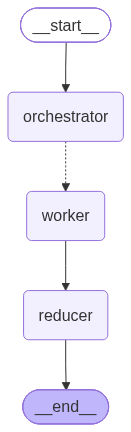

In [53]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [58]:
out = app.invoke({"topic": "Write a blog on encoder decoder make it short", "sections": []})

In [57]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Demystifying Self-Attention: From Theory to Practice', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the motivation behind attention in neural networks, contrasting it with traditional feed‑forward and convolutional models. Briefly cover the evolution from seq2seq attention to Transformer architectures.'), Task(id=2, title='Mathematics of Self‑Attention', brief='Dive into the core equations: queries, keys, values, dot‑product scaling, and the softmax weighting. Illustrate with a simple example and highlight the role of dimensionality and maskings.'), Task(id=3, title='Architecture of the Transformer Block', brief='Describe the multi‑head self‑attention layer, position‑wise feed‑forward network, residual connections, and layer normalization. Show how these components integrate into the overall Transformer encoder and decoder.'), Task(id=4, title='Computational Considerations', brief='D

In [56]:
print(out['plan'])

blog_title='Demystifying Self-Attention: From Theory to Practice' tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the motivation behind attention in neural networks, contrasting it with traditional feed‑forward and convolutional models. Briefly cover the evolution from seq2seq attention to Transformer architectures.'), Task(id=2, title='Mathematics of Self‑Attention', brief='Dive into the core equations: queries, keys, values, dot‑product scaling, and the softmax weighting. Illustrate with a simple example and highlight the role of dimensionality and maskings.'), Task(id=3, title='Architecture of the Transformer Block', brief='Describe the multi‑head self‑attention layer, position‑wise feed‑forward network, residual connections, and layer normalization. Show how these components integrate into the overall Transformer encoder and decoder.'), Task(id=4, title='Computational Considerations', brief='Discuss time‑ and memory‑complexity of self‑attention, commo